<a href="https://colab.research.google.com/github/nunotfc-png/Caeser-Cipher/blob/master/EX05_Detecao_Fraude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EX05 — Detecção de Fraude e Anomalias
**UC: Análise de Dados de Negócio**

---

Detecção de fraude com classes desequilibradas. SMOTE, Isolation Forest, LOF. Precision-Recall e optimização de threshold por custo de negócio.

**Dataset:** Credit Card Fraud (Kaggle ULB) — dados simulados incluídos no notebook

**Outputs gerados:** `transacoes_score_fraude.csv` · `precision_recall_fraude.png` · `threshold_cost.png`


In [24]:
# @title ⚙️ Instalação de Dependências (executar uma vez por sessão)
!pip install -q imbalanced-learn

In [25]:
# Dataset: Credit Card Fraud Detection (Kaggle ULB)
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# 284 807 transacções | 492 fraudes (0.17%)
# Features V1-V28: PCA anónimas | Amount, Time
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
BLUE, GREEN, RED = '#0891B2', '#0D9488', '#EF4444'

In [26]:
# Os ficheiros ficam em /content/ (sessão temporária):
OUTPUT_DIR = '/content/'
print(f"Directório de output: {OUTPUT_DIR}")

Directório de output: /content/


## PARTE 1 — CARREGAMENTO

In [32]:
from google.colab import files
uploaded = files.upload()

# Leitura de Ficheiro local (recomendado — ficheiro grande 144MB)
df = pd.read_csv('creditcard.csv')

Saving creditcard.csv to creditcard.csv


In [33]:
# Criar cópia do df com 1/4 dos dados
df = df.sample(frac=0.25, random_state=42)
print("Shape:", df.shape)

Shape: (71202, 31)


In [35]:
# Análise simples
print("Shape:", df.shape)
print("\nDistribuição de classes:")
print(df['Class'].value_counts())
print(f"Fraude: {df['Class'].mean()*100:.3f}%")

Shape: (71202, 31)

Distribuição de classes:
Class
0    71089
1      113
Name: count, dtype: int64
Fraude: 0.159%


In [ ]:
# Variáveis e tipos
df.info()

## PARTE 2 — ANÁLISE EXPLORATÓRIA DO DESEQUILÍBRIO

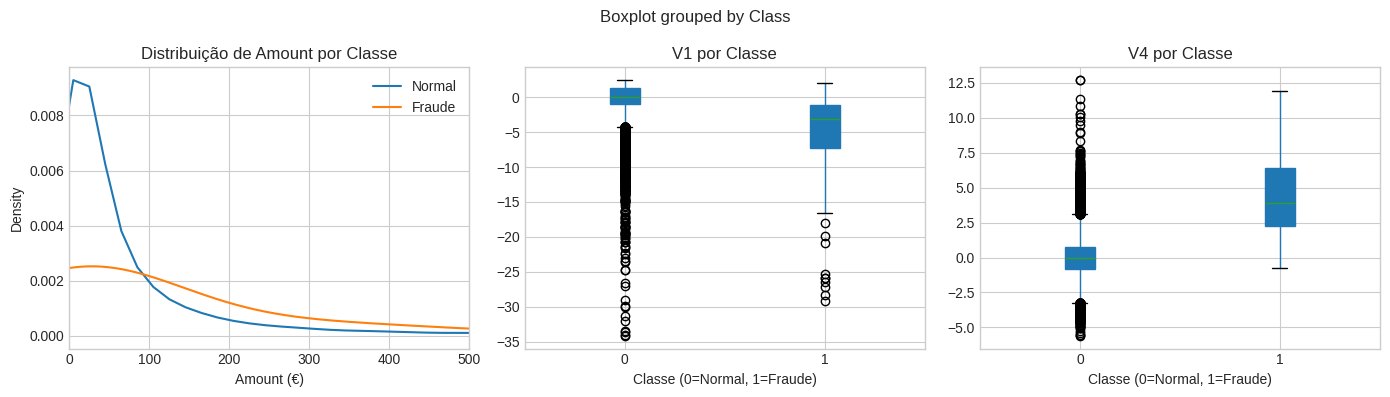

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribuição de Amount por classe
df.groupby('Class')['Amount'].plot(kind='kde', ax=axes[0])
axes[0].set_title('Distribuição de Amount por Classe')
axes[0].set_xlabel('Amount (€)')
axes[0].legend(['Normal', 'Fraude'])
axes[0].set_xlim(0, 500)

# Box plots de V1 e V2 (geralmente os mais discriminativos)
df.boxplot(column='V1', by='Class', ax=axes[1], patch_artist=True)
axes[1].set_title('V1 por Classe')
axes[1].set_xlabel('Classe (0=Normal, 1=Fraude)')

df.boxplot(column='V4', by='Class', ax=axes[2], patch_artist=True)
axes[2].set_title('V4 por Classe')
axes[2].set_xlabel('Classe (0=Normal, 1=Fraude)')

plt.tight_layout()
plt.savefig('/content/fraude_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 3 — PRÉ-PROCESSAMENTO E SMOTE

In [37]:
# Normalizar Amount e Time
scaler = StandardScaler()
df['Amount_sc'] = scaler.fit_transform(df[['Amount']])
df['Time_sc']   = scaler.fit_transform(df[['Time']])

# eliminar linhas com valores nulos
df.dropna(inplace=True)

In [38]:
# Criar datasets de treino e teste
features = [f'V{i}' for i in range(1, 29)] + ['Amount_sc', 'Time_sc']
X = df[features]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print(f"Treino: {y_train.value_counts().to_dict()}")
print(f"Teste:  {y_test.value_counts().to_dict()}")

Treino: {0: 53316, 1: 85}
Teste:  {0: 17773, 1: 28}


In [39]:
# Aplicar SMOTE ao treino
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"\nApós SMOTE (treino): {pd.Series(y_train_sm).value_counts().to_dict()}")


Após SMOTE (treino): {0: 53316, 1: 53316}


## PARTE 4 — MODELOS SUPERVISIONADOS

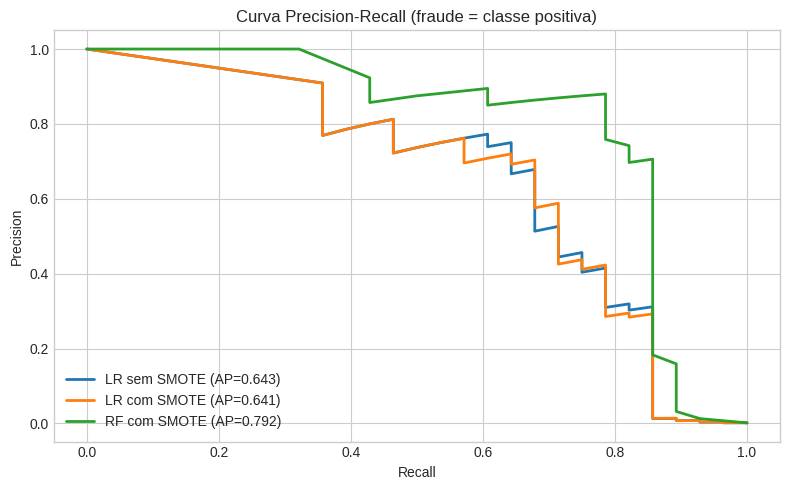

In [40]:
# 4A — Sem SMOTE
lr_raw = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_raw.fit(X_train, y_train)

# 4B — Com SMOTE
lr_sm = LogisticRegression(max_iter=1000, random_state=42)
lr_sm.fit(X_train_sm, y_train_sm)

rf_sm = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_sm.fit(X_train_sm, y_train_sm)

# Precision-Recall (melhor métrica para classes desequilibradas)
fig, ax = plt.subplots(figsize=(8, 5))
for name, model, X_tr, y_tr in [
    ('LR sem SMOTE', lr_raw, X_train, y_train),
    ('LR com SMOTE', lr_sm,  X_train_sm, y_train_sm),
    ('RF com SMOTE', rf_sm,  X_train_sm, y_train_sm)
]:
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f})', linewidth=2)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall (fraude = classe positiva)')
ax.legend()
plt.tight_layout()
plt.savefig('/content/precision_recall_fraude.png', dpi=150, bbox_inches='tight')
plt.show()

## PARTE 5 — DETECÇÃO DE ANOMALIAS NÃO-SUPERVISIONADA

In [41]:
# Isolation Forest
iso = IsolationForest(contamination=0.02, random_state=42)
iso.fit(X_train)
iso_pred = iso.predict(X_test)
iso_pred_bin = np.where(iso_pred == -1, 1, 0)  # -1 = anomalia → fraude

print("\n--- Isolation Forest ---")
print(classification_report(y_test, iso_pred_bin, target_names=['Normal', 'Fraude']))

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02, novelty=True)
lof.fit(X_train)
lof_pred_bin = np.where(lof.predict(X_test) == -1, 1, 0)

print("\n--- Local Outlier Factor ---")
print(classification_report(y_test, lof_pred_bin, target_names=['Normal', 'Fraude']))

# *** TAREFA: Compara os métodos supervisionados vs não supervisionados.
#     Qual o recall de cada um? Num sistema anti-fraude, qual métrica é mais crítica? ***


--- Isolation Forest ---
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     17773
      Fraude       0.06      0.71      0.10        28

    accuracy                           0.98     17801
   macro avg       0.53      0.85      0.55     17801
weighted avg       1.00      0.98      0.99     17801


--- Local Outlier Factor ---
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     17773
      Fraude       0.01      0.14      0.02        28

    accuracy                           0.98     17801
   macro avg       0.51      0.56      0.51     17801
weighted avg       1.00      0.98      0.99     17801



## PARTE 6 — THRESHOLD CUSTOMIZADO (BUSINESS DECISION)

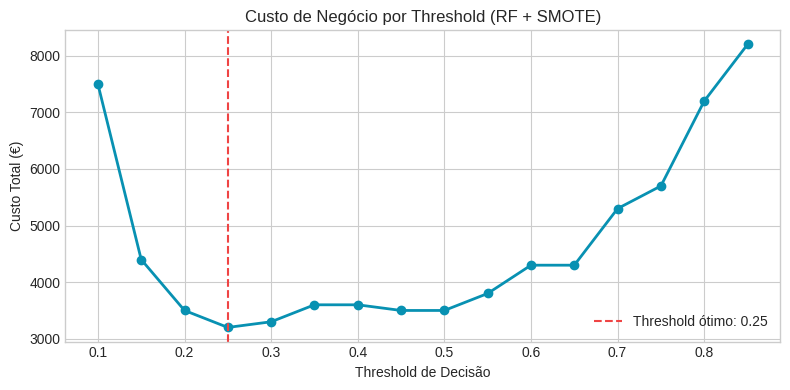


Threshold ótimo (min custo): 0.25
Custo mínimo: 3200€


In [42]:
# Considera: custo de FN (fraude não detectada) = 500€
#            custo de FP (alarme falso) = 50€ (revisão manual)

y_prob_rf = rf_sm.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
costs = []
for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    costs.append(fn * 500 + fp * 100)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, costs, marker='o', color=BLUE, linewidth=2)
ax.set_xlabel('Threshold de Decisão')
ax.set_ylabel('Custo Total (€)')
ax.set_title('Custo de Negócio por Threshold (RF + SMOTE)')
optimal_t = thresholds[np.argmin(costs)]
ax.axvline(optimal_t, color=RED, linestyle='--', label=f'Threshold ótimo: {optimal_t:.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('/content/threshold_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nThreshold ótimo (min custo): {optimal_t:.2f}")
print(f"Custo mínimo: {min(costs):.0f}€")


--- Threshold: 0.20000000000000007 ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     17773
      Fraude       0.62      0.86      0.72        28

    accuracy                           1.00     17801
   macro avg       0.81      0.93      0.86     17801
weighted avg       1.00      1.00      1.00     17801



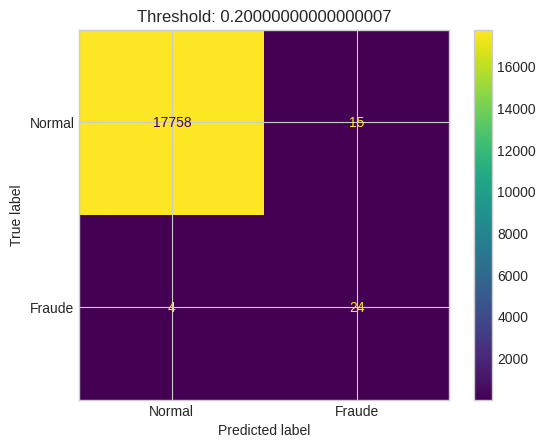

AUC: 0.957
AUC-ROC: 0.928

--- Threshold: 0.25000000000000006 ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     17773
      Fraude       0.67      0.86      0.75        28

    accuracy                           1.00     17801
   macro avg       0.83      0.93      0.87     17801
weighted avg       1.00      1.00      1.00     17801



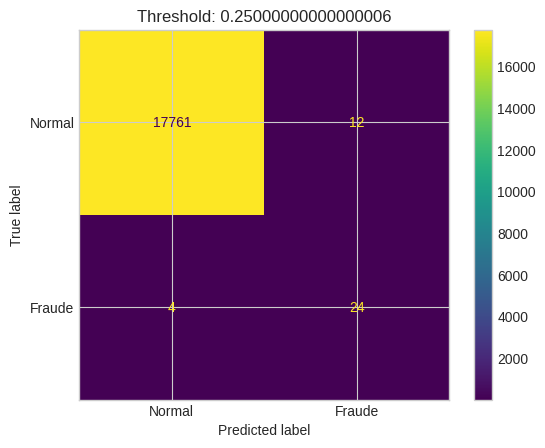

AUC: 0.957
AUC-ROC: 0.928

--- Threshold: 0.30000000000000004 ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     17773
      Fraude       0.74      0.82      0.78        28

    accuracy                           1.00     17801
   macro avg       0.87      0.91      0.89     17801
weighted avg       1.00      1.00      1.00     17801



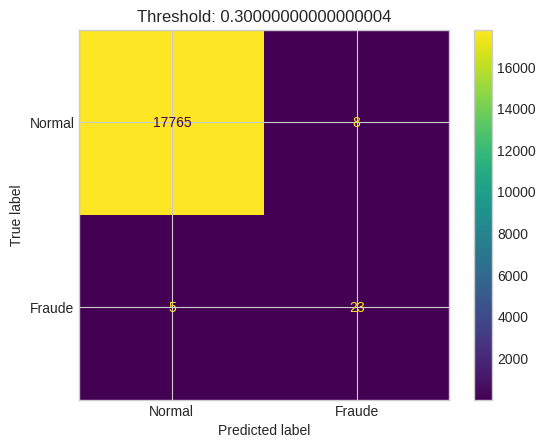

AUC: 0.957
AUC-ROC: 0.910


In [47]:
# Apresentar a matriz de confusão para os thresholds "otimo" - 0.05, "ótimo", "otimo" + 0.05
for t in [optimal_t - 0.05, optimal_t, optimal_t + 0.05]:
    y_pred_t = (y_prob_rf >= t).astype(int)
    print(f"\n--- Threshold: {t} ---")
    print(classification_report(y_test, y_pred_t, target_names=['Normal', 'Fraude']))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_t, display_labels=['Normal', 'Fraude'])
    plt.title(f'Threshold: {t}')
    plt.show()
    print(f"AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")
    print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_t):.3f}")

## PARTE 7 — EXPORTAR PARA POWER BI

In [48]:
df_test = X_test.copy()
df_test['Class_real'] = y_test.values
df_test['FraudProb']  = y_prob_rf
df_test['FraudPred']  = (y_prob_rf >= optimal_t).astype(int)
df_test['Amount']     = df.loc[X_test.index, 'Amount'].values

df_test.to_csv('/content/transacoes_score_fraude.csv', index=False)
print("Ficheiro 'transacoes_score_fraude.csv' guardado.")

Ficheiro 'transacoes_score_fraude.csv' guardado.


> PERGUNTAS DE REFLEXÃO

In [45]:
# 1. Por que a accuracy é uma métrica enganadora com classes desequilibradas?
#    Calcula a accuracy de um modelo que prevê sempre "Normal".
#
# 2. Qual o impacto de usar class_weight='balanced' vs SMOTE?
#    São estratégias equivalentes? Discute.
#
# 3. Um Isolation Forest tem recall baixo mas muitos menos FP.
#    Em que contexto de negócio preferirias este modelo?
#
# 4. EXTENSÃO: Experimenta um threshold diferente para cada faixa de Amount.
#    Faz sentido do ponto de vista de risco?